In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset/tesla_deliveries_dataset_2015_2025.csv')

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [2]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Data explanation: 
- Year & Month : time of data recorded
- Region : Where Tesla were delivered
- Model : Tesla Models
- Etimated_Delivery: Estimated number of Tesla dilivered in that month and region (per row)
- Production_Units: The number of Tesla vehicles produced during the same period
- Avg_Price_USD: The average selling price of the model in US dollars
- Battery_Capacity_kWh: The size of the battery in kilowatt-hours
- Range_km: The estimated driving range of the vehicle in kilometers
- CO2_Saved_tons: The estimated amount of CO₂ emissions saved due to electric vehicle usage, measured in tons.
- Sourche_Type: data collection sources
- Charging_Stations: Total charge station in that month and region (by row)


# Data Understanding

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


Insight: There are no missing value, all of data type are true

In [182]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.51,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


Insight: The data probably has outliers in several columns, so the outliers will check furthermore

In [183]:
df.duplicated().sum()

np.int64(0)

Insight: No duplicated data

In [184]:
for col in df[['Region', 'Model', 'Year']]:
    print((f"{col} : {df[col].unique()}"))

Region : ['Europe' 'Asia' 'North America' 'Middle East']
Model : ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Year : [2023 2015 2019 2021 2016 2020 2022 2025 2017 2024 2018]


Insight: The dataset collected from 2015–2025 shows Tesla's global growth across four major regions (Europe, Asia, North America, and the Middle East). Variations in the five major models ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck'] reflect product expansion and increasing EV adoption year over year.

# Cleaning

The data has no missing and duplicate values, so the cleaning process goes straight to outlier

### Outliers Check

In [185]:
df_num = df.select_dtypes(include='number').drop(columns=['Year', 'Month'])
df_num.columns

Index(['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='object')

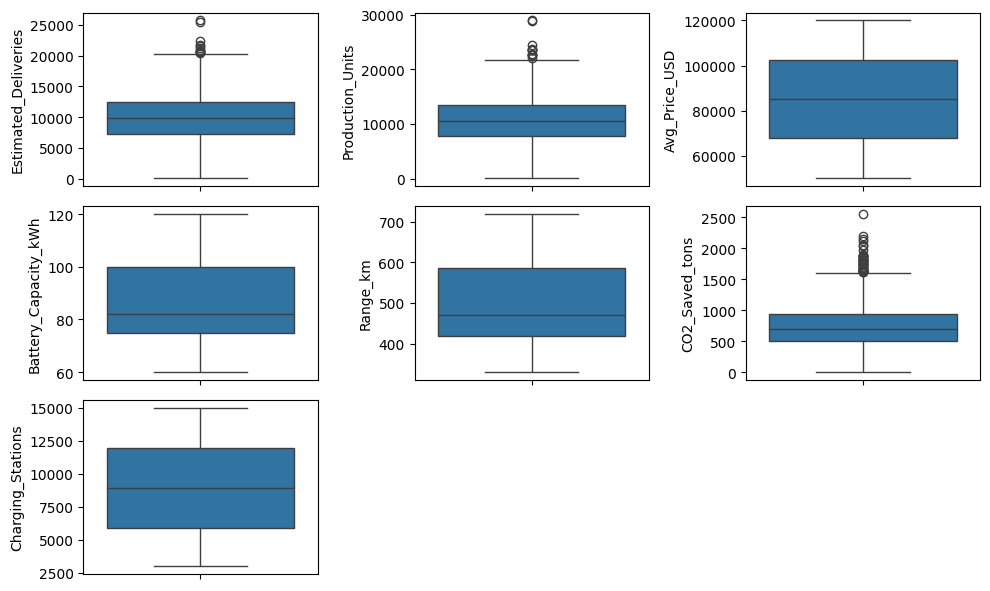

In [186]:
import math

n = len(df_num.columns)
cols = 3
rows = math.ceil(n/cols)

plt.figure(figsize=(10, 2*rows))
for i, col in enumerate(df_num.columns, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(df_num[col])
plt.tight_layout()
plt.show()

Insight: From the boxplot seen outliers in columns: Estimated_Deliveries, Production_Units, CO2_Saved_tons. For more insight will check outlier by IQR

In [187]:
for col in df[['Estimated_Deliveries', 'Production_Units', 'CO2_Saved_tons']]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1

    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)}")
    # print(outliers)

Estimated_Deliveries: 12
Production_Units: 12
CO2_Saved_tons: 45


Solution: 
- For analysis real data, the outliers will keep, because they are real condition. 
- But for modelling the outliers must be handling by transform or remove or keep

# Feature Engineering

In [188]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [189]:
final_data = df.copy()

### Drop useless columns

In [190]:
final_data = final_data.drop(columns=['Source_Type'])

### Date columns

In [191]:
datetime = pd.to_datetime(final_data[['Year', 'Month']].assign(Day=1))
final_data.insert(2, 'Datetime', datetime)

### Deliveries vs Production
- for checking stock and gap production the vechicles have not ordered yet

In [192]:
final_data['Gap_Product'] = final_data['Production_Units'] - final_data['Estimated_Deliveries']

### Revenue Approximation
- Estimated profit from all vehicles that have been ordered

In [193]:
final_data['Revenue_Approximation'] = final_data['Estimated_Deliveries'] * final_data['Avg_Price_USD']

### Battery Eficiency
- Estimate the distance traveled per kWh

In [194]:
final_data['Battery_Efficiency'] = final_data['Range_km'] / final_data['Battery_Capacity_kWh']

### Charging Station Ratio per region

- Estimate available ratio charging station per region

In [195]:
final_data['Charging_Stations_Ratio'] = (final_data['Charging_Stations'] / final_data['Estimated_Deliveries'])

### Check final data

In [196]:
pd.set_option('display.float_format', '{:.2f}'.format)
final_data.head()

,Year,Month,Datetime,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Gap_Product,Revenue_Approximation,Battery_Efficiency,Charging_Stations_Ratio
0,2023,5,2023-05-01,Europe,Model S,17646,17922,92874.27,120,704,1863.42,12207,276,1638859368.42,5.87,0.69
1,2015,2,2015-02-01,Asia,Model X,3797,4164,62205.65,75,438,249.46,7640,367,236194853.05,5.84,2.01
2,2019,1,2019-01-01,North America,Model X,8411,9189,117887.32,82,480,605.59,14071,778,991550248.52,5.85,1.67
3,2021,2,2021-02-01,North America,Model 3,6555,7311,89294.91,120,712,700.07,9333,756,585328135.05,5.93,1.42
4,2016,12,2016-12-01,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,8722,1163,1421114055.72,5.51,0.70


# Exploratory Data Analysis

### Distribute

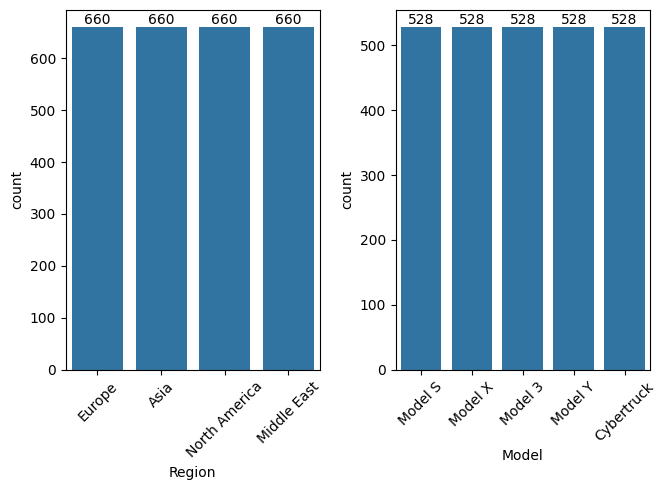

In [197]:
obj_cols = final_data.select_dtypes(include='object')

plt.figure(figsize=(10, 5))
for i, col in enumerate(obj_cols.columns, 1):
    plt.subplot(1,3, i)
    ax = sns.countplot(x = final_data[col])
    for c in ax.containers:
        plt.bar_label(c)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

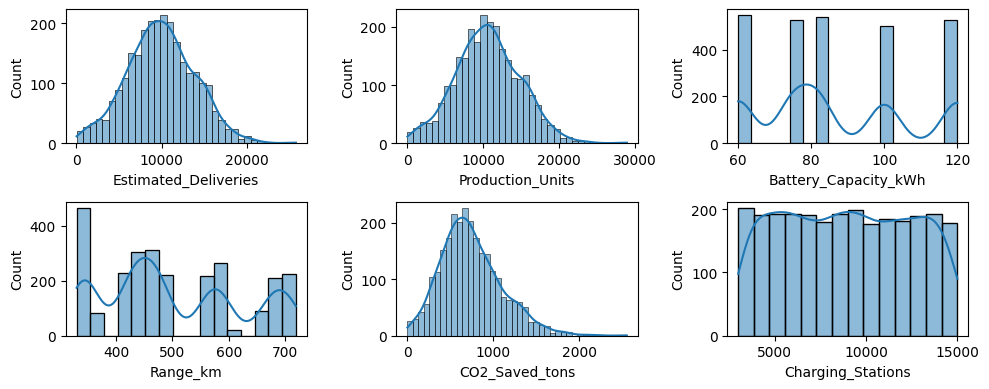

In [198]:
num_cols =  final_data[['Estimated_Deliveries', 'Production_Units', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']]

n = len(num_cols.columns)
cols = 3
rows = math.ceil(n/cols)

plt.figure(figsize=(10, 2*rows))
for i, col in enumerate(num_cols.columns, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(x = final_data[col], kde=True)
plt.tight_layout()
plt.show()

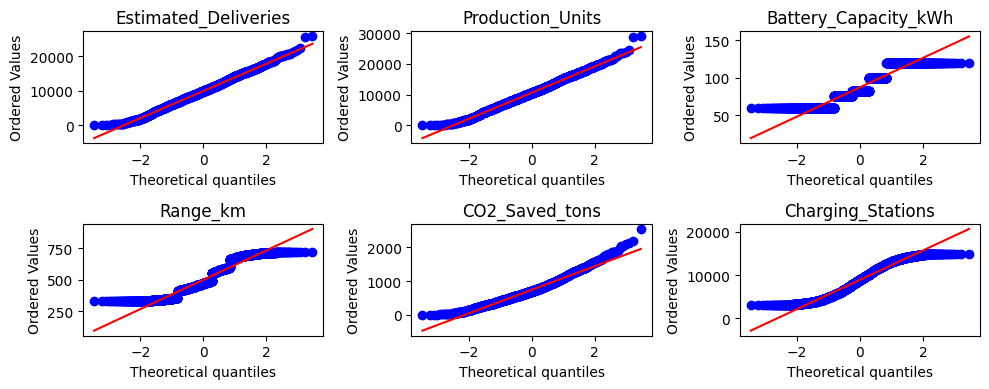

In [199]:
import scipy.stats as stats

plt.figure(figsize=(10, 2*rows))
for i, col in enumerate(num_cols.columns, 1):
    plt.subplot(rows, cols, i)
    stats.probplot(final_data[col], dist='norm', plot=plt)
    plt.title(col)
plt.tight_layout()
plt.show()

Insight: 
- Estimated_Deliveries, Production_Units, and CO2_Saved_tons show near-normal distributions.
- Battery_Capacity_kWh, Range_km, and Charging_Stations have non-normal or categorical distributions.
- Examining the distributions helps understand the data's character, and for analysis in Tableau, the data does not need to be transformed to maintain the original pattern.

# Correlation

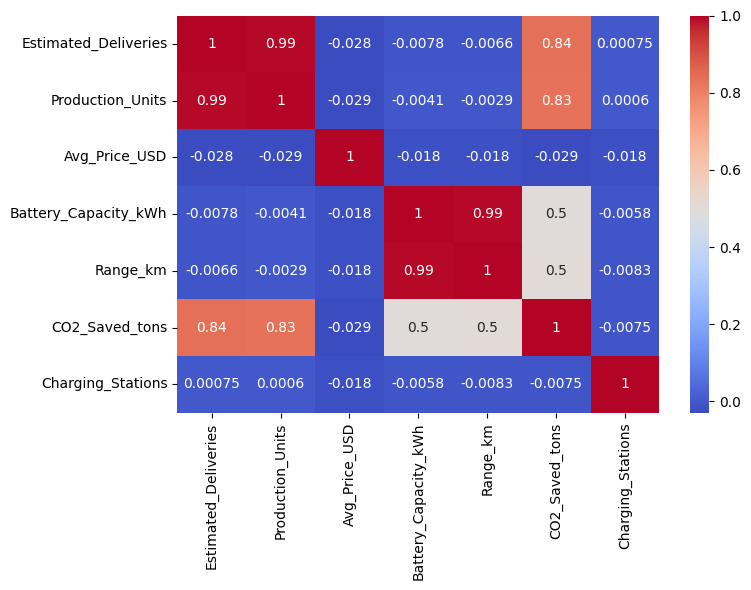

In [200]:
correlation = final_data[['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']]

plt.figure(figsize=(8,6))
sns.heatmap(correlation.corr(), annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()

Insight:

- Estimated_Deliveries and Production_Units have a very high correlation, while Battery_Capacity_kWh and Range_km also show a near-perfect relationship.
- CO2_Saved_tons correlates strongly with Estimated_Deliveries and Production_Units, while Avg_Price_USD and Charging_Stations have almost no linear relationship with the other variables.
- These correlation patterns help understand the structure of the relationships between features, and for Tableau analysis, no transformation is required to maintain the original pattern.

# Save Clean Data

In [201]:
final_data.to_excel('dataset/clean_data.xlsx', index=False)